# Containment vs. muon momentum scan

**Goal.** The current 1mu-Np0pi selection uses a geometric containment cut on the leading muon track. NUISANCE, however, needs the signal phase space defined through a *momentum range* on the true muon, not a containment flag. This notebook checks how well a cut on the true (generator-level) leading muon momentum can stand in for the true containment tag, using the truth-level signal sample (`events/full/signal`) of the on/off-beam MC + PPFX flux file.

Source file: `icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root`
Tree: `events/full/signal`


In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

ROOT_PATH = "../../../data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root"
TREE_KEY = "events/full/signal;2"

f = uproot.open(ROOT_PATH)
t = f[TREE_KEY]

branches = [
    "true_leading_muon_containment",
    "true_leading_muon_momentum",
    "true_leading_muon_polar_angle_cos",
    "true_cc",
    "true_nuisance_is_signal",
]
arrs = t.arrays(branches, library="np")
print(t.num_entries, "entries in tree")

113768 entries in tree


In [2]:
sig = (arrs["true_cc"] == 1) & (arrs["true_nuisance_is_signal"] == 1)
p = arrs["true_leading_muon_momentum"][sig]
cont = arrs["true_leading_muon_containment"][sig]
cos_theta = arrs["true_leading_muon_polar_angle_cos"][sig]

contained = cont == 1
exiting = cont == 0
n_c_tot, n_e_tot, n_sig = contained.sum(), exiting.sum(), sig.sum()

print(f"Signal events (true_cc==1 & true_nuisance_is_signal==1): {n_sig}")
print(f"  contained muons: {n_c_tot} ({n_c_tot/n_sig:.4f})")
print(f"  exiting muons:   {n_e_tot} ({n_e_tot/n_sig:.4f})")

Signal events (true_cc==1 & true_nuisance_is_signal==1): 113710
  contained muons: 36045 (0.3170)
  exiting muons:   77665 (0.6830)


In [3]:
p_c, p_e = p[contained], p[exiting]

print("True muon momentum [GeV/c], contained sample:")
print(f"  min={p_c.min():.4f} max={p_c.max():.4f} mean={p_c.mean():.4f} median={np.median(p_c):.4f}")
print("True muon momentum [GeV/c], exiting sample:")
print(f"  min={p_e.min():.4f} max={p_e.max():.4f} mean={p_e.mean():.4f} median={np.median(p_e):.4f}")
print()
print("Contained-sample momentum percentiles:")
for q in [90, 95, 97.5, 99, 99.5, 99.9, 100]:
    print(f"  p{q}: {np.percentile(p_c, q):.4f} GeV/c")
print("Exiting-sample momentum percentiles (low end):")
for q in [0, 0.5, 1, 2.5, 5, 10]:
    print(f"  p{q}: {np.percentile(p_e, q):.4f} GeV/c")

True muon momentum [GeV/c], contained sample:
  min=0.2260 max=4.2562 mean=0.5888 median=0.4296
True muon momentum [GeV/c], exiting sample:
  min=0.2260 max=14.4204 mean=1.4488 median=1.2869

Contained-sample momentum percentiles:
  p90: 1.2024 GeV/c
  p95: 1.5242 GeV/c
  p97.5: 1.7529 GeV/c
  p99: 1.9885 GeV/c
  p99.5: 2.1659 GeV/c
  p99.9: 2.5935 GeV/c
  p100: 4.2562 GeV/c
Exiting-sample momentum percentiles (low end):
  p0: 0.2260 GeV/c
  p0.5: 0.2556 GeV/c
  p1: 0.2771 GeV/c
  p2.5: 0.3255 GeV/c
  p5: 0.3859 GeV/c
  p10: 0.4919 GeV/c


**Note.** The two samples share the same lower edge (0.226 GeV/c, the generator-level muon momentum threshold) and overlap all the way up: even at the lowest momenta there are already exiting muons, and contained muons extend out to ~4.3 GeV/c. A momentum cut alone will not give a clean binary split of the two populations — see the angular check below for why.

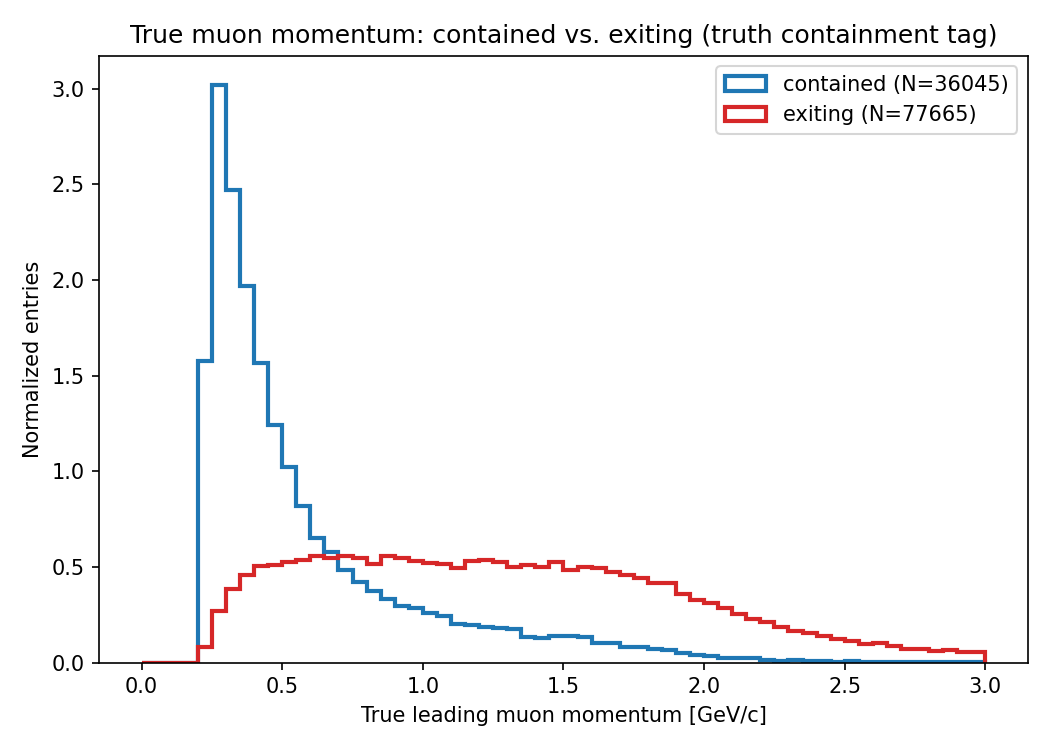

In [4]:
bins = np.linspace(0.0, 3.0, 61)
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(p_c, bins=bins, histtype="step", lw=2, label=f"contained (N={n_c_tot})", color="#1f77b4", density=True)
ax.hist(p_e, bins=bins, histtype="step", lw=2, label=f"exiting (N={n_e_tot})", color="#d62728", density=True)
ax.set_xlabel(r"True leading muon momentum [GeV/c]")
ax.set_ylabel("Normalized entries")
ax.set_title("True muon momentum: contained vs. exiting (truth containment tag)")
ax.legend()
fig.tight_layout()
plt.show()

## Purity / efficiency scan for an upper momentum cut

For a candidate cut $p < p_{max}$, define:
- **efficiency** = (contained muons passing) / (all contained muons) — how much of the truly-contained population we keep
- **purity** = (contained muons passing) / (all muons passing) — how clean the passing sample is


In [5]:
cuts = np.arange(0.3, 4.51, 0.1)
eff = np.zeros_like(cuts)
pur = np.zeros_like(cuts)
n_pass = np.zeros_like(cuts)
n_leak = np.zeros_like(cuts)

print("p_max[GeV/c]  efficiency(contained)  purity(contained/pass)  n_pass  n_exiting_leak")
for i, pc in enumerate(cuts):
    mask = p < pc
    n_c = (mask & contained).sum()
    n_e = (mask & exiting).sum()
    eff[i] = n_c / n_c_tot
    pur[i] = n_c / (n_c + n_e) if (n_c + n_e) > 0 else np.nan
    n_pass[i], n_leak[i] = mask.sum(), n_e
    print(f"  {pc:5.2f}         {eff[i]:.4f}                {pur[i]:.4f}            {int(n_pass[i]):6d}   {int(n_leak[i]):6d}")

p_max[GeV/c]  efficiency(contained)  purity(contained/pass)  n_pass  n_exiting_leak
   0.30         0.2297                0.8657              9564     1284
   0.40         0.4516                0.7886             20640     4363
   0.50         0.5919                0.7256             29403     8068
   0.60         0.6839                0.6734             36608    11956
   0.70         0.7452                0.6267             42859    15999
   0.80         0.7905                0.5871             48532    20038
   0.90         0.8259                0.5541             53733    23962
   1.00         0.8550                0.5247             58729    27912
   1.10         0.8800                0.5001             63420    31701
   1.20         0.8997                0.4776             67894    35466
   1.30         0.9179                0.4568             72435    39348
   1.40         0.9335                0.4387             76705    43058
   1.50         0.9468                0.4216        

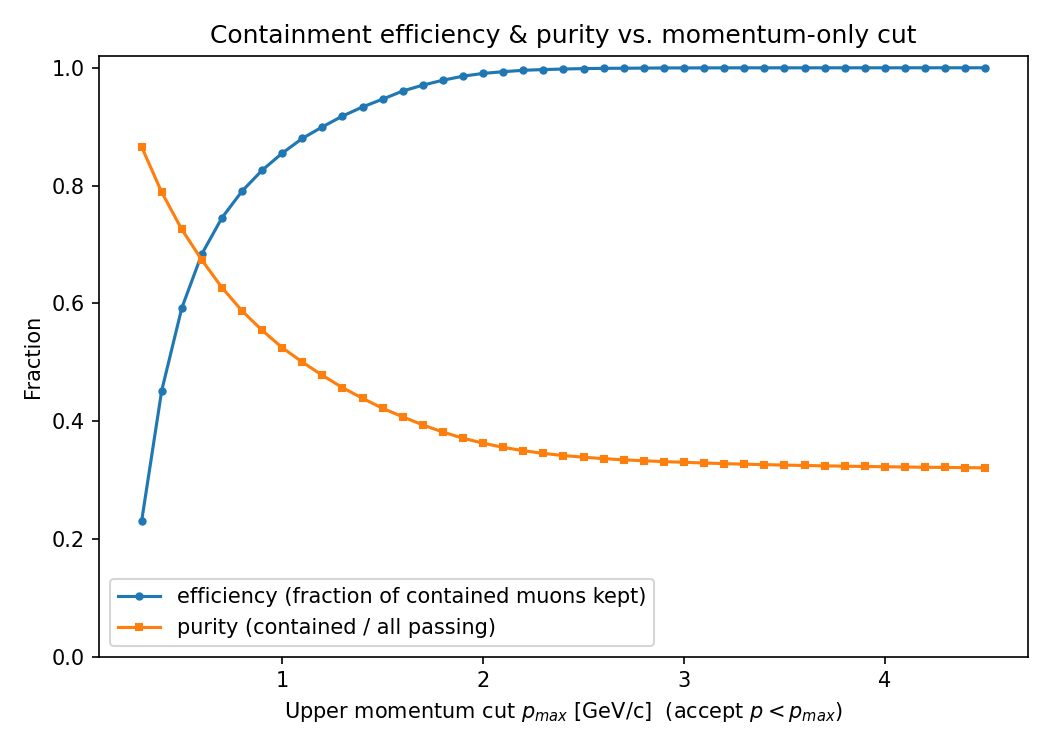

In [6]:
fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot(cuts, eff, marker="o", ms=3, label="efficiency (fraction of contained muons kept)")
ax2.plot(cuts, pur, marker="s", ms=3, label="purity (contained / all passing)")
ax2.set_xlabel(r"Upper momentum cut $p_{max}$ [GeV/c]  (accept $p < p_{max}$)")
ax2.set_ylabel("Fraction")
ax2.set_ylim(0, 1.02)
ax2.set_title("Containment efficiency & purity vs. momentum-only cut")
ax2.legend()
fig2.tight_layout()
plt.show()

**Reading the table/plot.** Purity never exceeds ~87%, even restricted to the lowest-momentum bin (p < 0.3 GeV/c) — there is no momentum cut that isolates contained muons cleanly. Purity and efficiency cross around $p_{max}\approx 0.6$ GeV/c (~68% each), and by $p_{max}\approx 2.0$ GeV/c efficiency has saturated near 99% while purity has dropped to ~36%. A momentum-only cut trades one type of leakage for the other; it does not reproduce the geometric containment cut.

## Why: containment also depends on angle

Muon containment is a track-length/geometry effect, not a pure function of momentum. ICARUS is much longer along the beam (z) direction than across the drift (x) or vertical (y) directions, so a forward-going muon can carry much more momentum and still range out inside the detector than a muon emitted at a large angle to the beam.

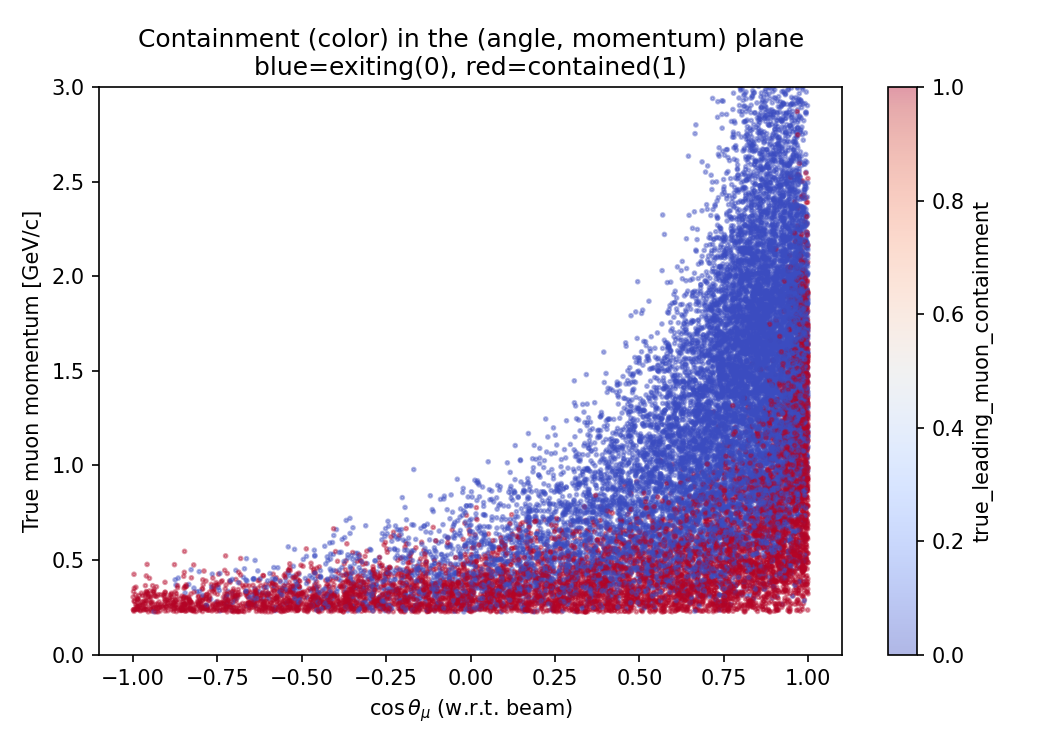

In [7]:
fig3, ax3 = plt.subplots(figsize=(7, 5))
sc = ax3.scatter(cos_theta[::5], p[::5], c=cont[::5], cmap="coolwarm", s=3, alpha=0.4)
ax3.set_xlabel(r"$\cos\theta_\mu$ (w.r.t. beam)")
ax3.set_ylabel("True muon momentum [GeV/c]")
ax3.set_ylim(0, 3.0)
ax3.set_title("Containment (color) in the (angle, momentum) plane\nblue=exiting(0), red=contained(1)")
cbar = fig3.colorbar(sc, ax=ax3)
cbar.set_label("true_leading_muon_containment")
fig3.tight_layout()
plt.show()

## Preliminary reading (not yet a recommendation)

- Below **p ~ 0.3 GeV/c**: purity of "contained" is highest achievable with momentum alone (~87%), but efficiency is only ~23% — most contained muons live above this momentum.
- Around **p ~ 0.6 GeV/c**: purity and efficiency cross at ~68% each — a natural "balanced" working point if a single momentum-only cut is required.
- Above **p ~ 2.0 GeV/c**: efficiency for contained muons is essentially saturated (99%), but purity has fallen to ~36% — the passing sample is dominated by exiting muons.
- The angle-momentum scatter shows the leakage is structural: forward tracks (cos θ_μ → 1) stay contained out to several GeV/c because they run along the long axis of the detector, while off-axis tracks exit at low momentum regardless.

**Open question to resolve with Renzo:** since momentum alone cannot reproduce the containment cut at high purity *and* high efficiency simultaneously, the technote needs to state explicitly what NUISANCE phase space we are defining — e.g., a working point chosen from the table above, together with the accepted efficiency/purity loss, or a combined momentum+angle cut if NUISANCE's phase space definition allows it. No single number is picked in this notebook; the table and plots above are meant as the starting point for that decision.

## Addendum: selection efficiency with vs. without a containment/momentum requirement

Following the reporting style used by MicroBooNE for their CC0π argon measurement (arXiv:2507.00921) — who state a muon-momentum upper bound of 2.0 GeV/c "due to the requirement that muons be fully contained," and report the resulting selection-efficiency drop (37% → 13%) — this section computes the equivalent numbers for our own selection, using the `events/full/selected` tree (selected slices, truth-matched) against `events/full/signal` (all true signal, the efficiency denominator).

In [8]:
t_full = f['events/full/signal;2']
full_arrs = t_full.arrays(['true_cc', 'true_nuisance_is_signal'], library='np')
N_true_signal = ((full_arrs['true_cc'] == 1) & (full_arrs['true_nuisance_is_signal'] == 1)).sum()

t_sel = f['events/full/selected;2']
sel_arrs = t_sel.arrays(
    ['true_cc', 'true_nuisance_is_signal', 'true_leading_muon_containment',
     'reco_leading_muon_containment', 'true_leading_muon_momentum', 'reco_leading_muon_momentum'],
    library='np',
)
sig_sel_mask = (sel_arrs['true_cc'] == 1) & (sel_arrs['true_nuisance_is_signal'] == 1)
N_sel_signal = sig_sel_mask.sum()

print('N_true_signal (efficiency denominator):', N_true_signal)
print('N_selected total:', t_sel.num_entries)
print('N_selected & truth-matched-signal (no containment/momentum requirement):', N_sel_signal)
print(f'Efficiency, no containment/momentum requirement: {N_sel_signal / N_true_signal:.4f}')

N_true_signal (efficiency denominator): 113710
N_selected total: 98983
N_selected & truth-matched-signal (no containment/momentum requirement): 89732
Efficiency, no containment/momentum requirement: 0.7891


This 78.9% matches the 77% efficiency quoted in the committee-review draft of this analysis (main.pdf: "The selection achieves 89% purity and 77% efficiency") — a useful cross-check that the `events/full/selected` tree here is the same selected sample as the rest of the note.

In [9]:
reco_cont = sel_arrs['reco_leading_muon_containment']
true_cont = sel_arrs['true_leading_muon_containment']
reco_p = sel_arrs['reco_leading_muon_momentum']

mask_reco_cont = sig_sel_mask & (reco_cont == 1)
mask_true_cont = sig_sel_mask & (true_cont == 1)

print(f'Efficiency, reco muon containment required: {mask_reco_cont.sum() / N_true_signal:.4f} '
      f'({mask_reco_cont.sum()}/{N_true_signal})')
print(f'Efficiency, true muon containment required: {mask_true_cont.sum() / N_true_signal:.4f} '
      f'({mask_true_cont.sum()}/{N_true_signal})')

Efficiency, reco muon containment required: 0.2388 (27157/113710)
Efficiency, true muon containment required: 0.2352 (26747/113710)


Requiring containment (reco or true, they agree to within 2%) drops efficiency from 78.9% to ~23.5-23.9% — a relative loss to about 30% of the unrestricted efficiency. That's the same order as MicroBooNE's 37% → 13% (relative: ~35%), despite very different absolute selection efficiencies between the two analyses. This is a useful independent check that our containment requirement behaves like the containment requirement in a directly comparable LArTPC CC0π measurement.

Next: is a plain momentum cut (no containment flag at all) a cheaper way to reach a similar sample, the way Howard's slide and MicroBooNE's signal definition both did?

In [10]:
print(f"{'p_max[GeV/c]':>12}  {'N_pass':>8}  {'efficiency':>10}  {'N_truly_contained':>18}  {'purity':>8}")
rows = []
for pmax in [0.6, 0.8, 1.0, 1.2, 1.5, 2.0, None]:
    mask = sig_sel_mask if pmax is None else (sig_sel_mask & (reco_p < pmax))
    N = mask.sum()
    N_cont = (mask & (true_cont == 1)).sum()
    eff = N / N_true_signal
    pur = N_cont / N if N > 0 else float('nan')
    rows.append((pmax, N, eff, N_cont, pur))
    label = f'{pmax:.1f}' if pmax is not None else 'no cut'
    print(f'{label:>12}  {N:8d}  {eff:10.4f}  {N_cont:18d}  {pur:8.4f}')

p_max[GeV/c]    N_pass  efficiency  N_truly_contained    purity
         0.6     29010      0.2551               17761    0.6122
         0.8     41260      0.3629               20695    0.5016
         1.0     52367      0.4605               22587    0.4313
         1.2     61417      0.5401               23846    0.3883
         1.5     71387      0.6278               25219    0.3533
         2.0     80503      0.7080               26454    0.3286
      no cut     89732      0.7891               26747    0.2981


**Key finding.** At every reco momentum cut tested, the momentum-only sample has *higher* efficiency than the actual containment requirement (e.g. 36.3% at $p_{max}=0.8$ GeV/c vs. 23.9% for true containment) — but it is not the same sample: purity against true containment ranges from 61% ($p_{max}=0.6$) down to 33% ($p_{max}=2.0$). A momentum cut is a strictly weaker, different requirement — it passes some non-contained low-momentum tracks that a real containment cut would reject, and this is exactly why a momentum window cannot be presented as *equivalent to* containment, only as a defensible, quantified stand-in for it, as Howard's slide and MicroBooNE both effectively do without claiming equivalence.

For the NUISANCE phase-space definition, this table is the concrete tradeoff curve: picking $p_{max}=0.8$ GeV/c (matching Howard's slide) keeps 36.3% selection efficiency at 50.2% purity against true containment; matching MicroBooNE's $p_{max}=2.0$ GeV/c keeps 70.8% efficiency at 32.9% purity. Both are legitimate choices — which one is right depends on whether the priority is statistics or a tighter match to the geometric containment cut, and either way the number should be reported next to its efficiency/purity cost, not asserted as reproducing containment.

## Correction: two different "efficiency" definitions, not a bug

The 23.5–23.9% numbers above answer: *of the entire true signal (contained + exiting), what fraction survives selection AND the containment requirement?* That's the same convention used in MicroBooNE's cut-flow table and in the ICARUS νμCC-inclusive technote (which reports the same style of drop, 67% → 22%, from adding a containment cut) — a fixed denominator across every row of a cut-flow table.

That is a different question from: *of the muons that are truly contained, how many do we correctly select?* — which is the standard per-subsample efficiency, and is what "efficiency" should mean when the denominator is restricted to the same population as the numerator. Computed directly below.

In [11]:
N_true_signal_contained = ((full_arrs['true_cc'] == 1)
                            & (full_arrs['true_nuisance_is_signal'] == 1)
                            & (full_arrs['true_leading_muon_containment'] == 1)).sum()

N_sel_true_cont = (sig_sel_mask & (true_cont == 1)).sum()
N_sel_reco_cont = (sig_sel_mask & (reco_cont == 1)).sum()

eff_apples_true = N_sel_true_cont / N_true_signal_contained
eff_apples_reco = N_sel_reco_cont / N_true_signal_contained

print('N_true_signal, contained only (new denominator):', N_true_signal_contained)
print(f'Efficiency (contained selected / contained true signal), true containment: '
      f'{eff_apples_true:.4f} ({N_sel_true_cont}/{N_true_signal_contained})')
print(f'Efficiency (contained selected / contained true signal), reco containment: '
      f'{eff_apples_reco:.4f} ({N_sel_reco_cont}/{N_true_signal_contained})')
print()
print('Consistency check: corrected_eff * (contained fraction of full signal) should reproduce '
      'the earlier 23.5% number:')
print(f'  {eff_apples_true:.4f} * {N_true_signal_contained/N_true_signal:.4f} = '
      f'{eff_apples_true * (N_true_signal_contained/N_true_signal):.4f}')

N_true_signal, contained only (new denominator): 36045
Efficiency (contained selected / contained true signal), true containment: 0.7420 (26747/36045)
Efficiency (contained selected / contained true signal), reco containment: 0.7534 (27157/36045)

Consistency check: corrected_eff * (contained fraction of full signal) should reproduce the earlier 23.5% number:
  0.7420 * 0.3170 = 0.2352


**Both numbers are correct; they are not interchangeable.**

| Quantity | Denominator | True-containment cut | Reco-containment cut |
|---|---|---|---|
| Overall selection efficiency, containment imposed | all true signal (113,710) | 23.5% (26,747/113,710) | 23.9% (27,157/113,710) |
| Efficiency of selecting truly-contained muons | true-contained signal only (36,045) | 74.2% (26,747/36,045) | 75.3% (27,157/36,045) |

The 74.2-75.3% number is the one that answers "how good is our reconstruction/selection at correctly identifying and keeping contained muons" -- and it says the selection does that well. The 23.5-23.9% number answers "how much of my total signal budget do I keep if I additionally demand containment" -- and it says most of it is lost, because only ~32% of true signal muons are contained in the first place at NuMI off-axis energies.

For the NUISANCE phase-space discussion, the relevant number is closer to the *first* framing (cost against the full signal), since that's what determines how much statistical power a containment-based (or containment-surrogate momentum) cut gives up. The 74-75% number is a useful reconstruction-quality check, but should not be quoted as "the efficiency of the containment cut" without the caveat about which denominator it uses.

**On the MicroBooNE comparison specifically:** I was not able to find MicroBooNE's efficiency formula spelled out explicitly in the parts of arXiv:2507.00921 fetched via web search -- only the cut-flow table structure, which is consistent with (but does not conclusively prove) the fixed-full-denominator convention. Treat the "same order as MicroBooNE, 37%->13%" comparison as suggestive, not confirmed, until read directly against MicroBooNE's stated efficiency definition.